In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.colors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Загрузка и первичный анализ данных

In [26]:
df = pd.read_csv(r'C:\Users\User\Desktop\Проект CaseBridge\data\freelance_tasks_final - freelance_tasks_final.csv')
df.head()

,id,наименование_задачи,тип_задачи,технологический_стек,срок_выполнения_дней,цена_руб,ценовой_диапазон
0,1,Синхронизация CRM и 1С,Автоматизация и скрипты,Zapier+Python,14,7000,5 000–15 000 ₽
1,2,Приложение учёта финансов,Мобильное приложение,Flutter,31,33200,30 000–60 000 ₽
2,3,Приложение трекинга тренировок,Мобильное приложение,React Native+Redux,10,70000,60 000–120 000 ₽
3,4,Вёрстка личного кабинета,Вёрстка,HTML+CSS+BEM,12,3500,до 5 000 ₽
4,5,Каталог с корзиной на Flutter,Мобильное приложение,React Native+TS,40,69000,60 000–120 000 ₽


In [27]:
print(df["ценовой_диапазон"].value_counts())
df.describe()

ценовой_диапазон
5 000–15 000 ₽      1560
15 000–30 000 ₽      535
до 5 000 ₽           382
30 000–60 000 ₽      323
60 000–120 000 ₽     197
свыше 120 000 ₽        3
Name: count, dtype: int64


,id,срок_выполнения_дней,цена_руб
count,3000.000000,3000.000000,3000.000000
mean,1500.500000,13.062667,18362.000000
std,866.169729,11.737404,20184.316309
min,1.000000,1.000000,2000.000000
25%,750.750000,5.000000,6000.000000
50%,1500.500000,10.000000,10000.000000
75%,2250.250000,16.000000,20725.000000
max,3000.000000,60.000000,136500.000000


In [28]:

print("Пропущенные значения")
print(df.isnull().sum())
print("\n Процент недостающих значений: ")
print((df.isnull().sum() / len(df) * 100).round(2) )
print("\nБаланс классов ДО объединения:")
print(df["ценовой_диапазон"].value_counts(normalize=True).round(3))


print("\nПолных дублирующихся строк:", df.duplicated().sum(),"\n")

print(df.dtypes)

df.shape

Пропущенные значения
id                      0
наименование_задачи     0
тип_задачи              0
технологический_стек    0
срок_выполнения_дней    0
цена_руб                0
ценовой_диапазон        0
dtype: int64

 Процент недостающих значений: 
id                      0.0
наименование_задачи     0.0
тип_задачи              0.0
технологический_стек    0.0
срок_выполнения_дней    0.0
цена_руб                0.0
ценовой_диапазон        0.0
dtype: float64

Баланс классов ДО объединения:
ценовой_диапазон
5 000–15 000 ₽      0.520
15 000–30 000 ₽     0.178
до 5 000 ₽          0.127
30 000–60 000 ₽     0.108
60 000–120 000 ₽    0.066
свыше 120 000 ₽     0.001
Name: proportion, dtype: float64

Полных дублирующихся строк: 0 

id                      int64
наименование_задачи       str
тип_задачи                str
технологический_стек      str
срок_выполнения_дней    int64
цена_руб                int64
ценовой_диапазон          str
dtype: object


(3000, 7)

### Вывод

Датасет не содержит критических проблем. Стоимость имеет асимметричное распределение, поэтому далее будет использована log-трансформация.

# Разведочный анализ данных (EDA)

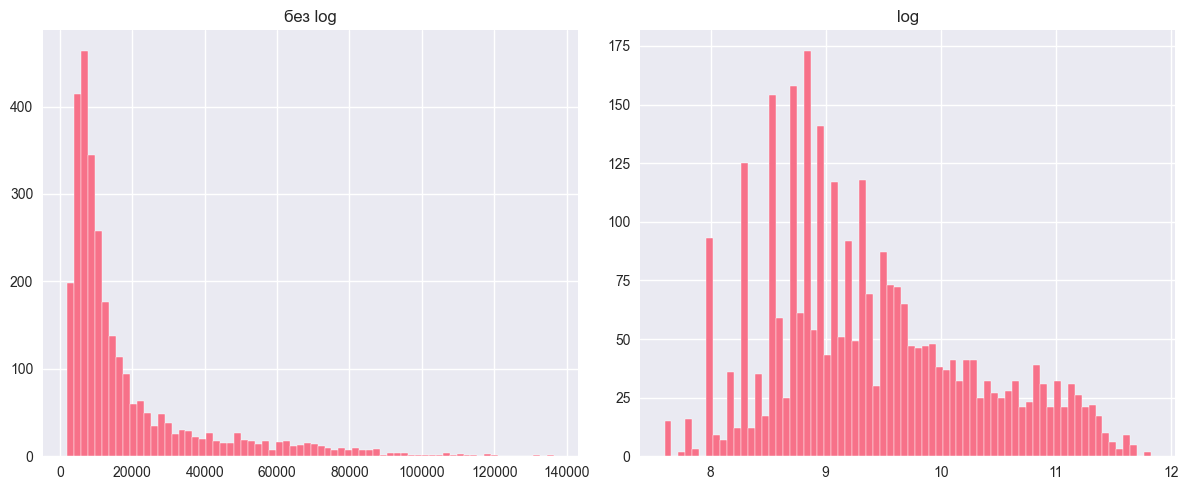

Скошенность до log: 2.22
Скошенность после log: 0.534


In [29]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].hist(df["цена_руб"], bins = 70)
axes[1].hist(np.log(df["цена_руб"]), bins = 70)
axes[0].set_title("без log")
axes[1].set_title("log")
plt.tight_layout()
plt.show()

print(f"Скошенность до log: {df["цена_руб"].skew():.3}")

log_price = np.log(df["цена_руб"])
print(f"Скошенность после log: {log_price.skew():.3}")

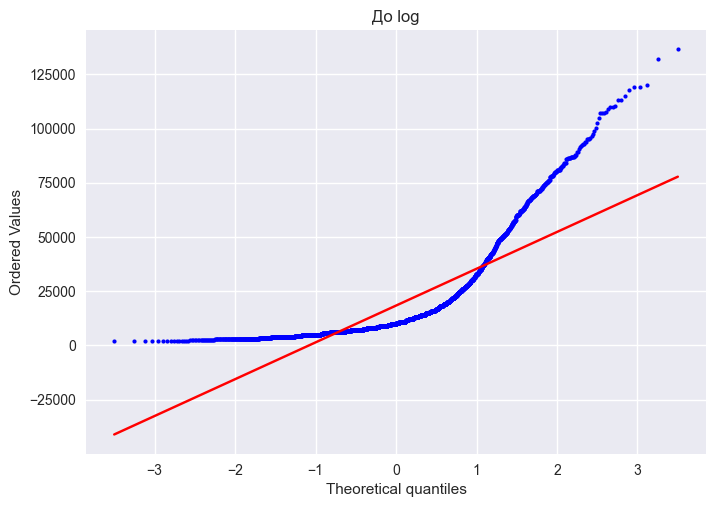

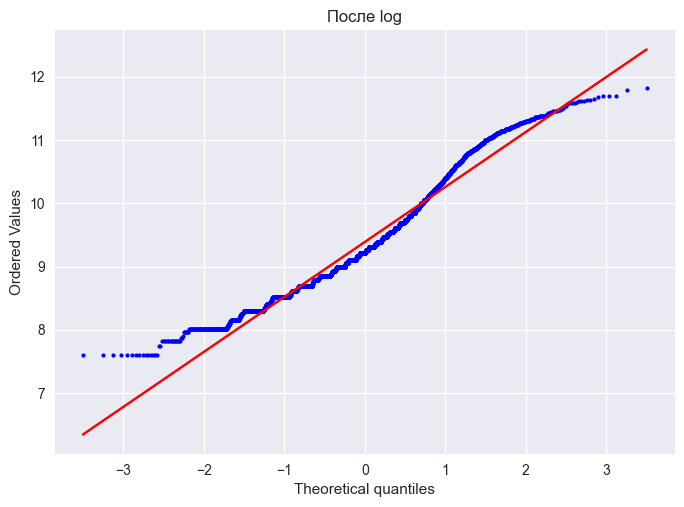

In [30]:

stats.probplot(df["цена_руб"], dist="norm", plot=plt)
plt.title("До log")
plt.gca().get_lines()[0].set_markersize(3)
plt.show()

stats.probplot(np.log(df["цена_руб"]), dist="norm", plot=plt)
plt.title("После log")
plt.gca().get_lines()[0].set_markersize(3)
plt.show()

### Вывод

Распределение стоимости сильно скошено вправо. После логарифмирования распределение становится более близким к нормальному.

<Axes: ylabel='тип_задачи'>

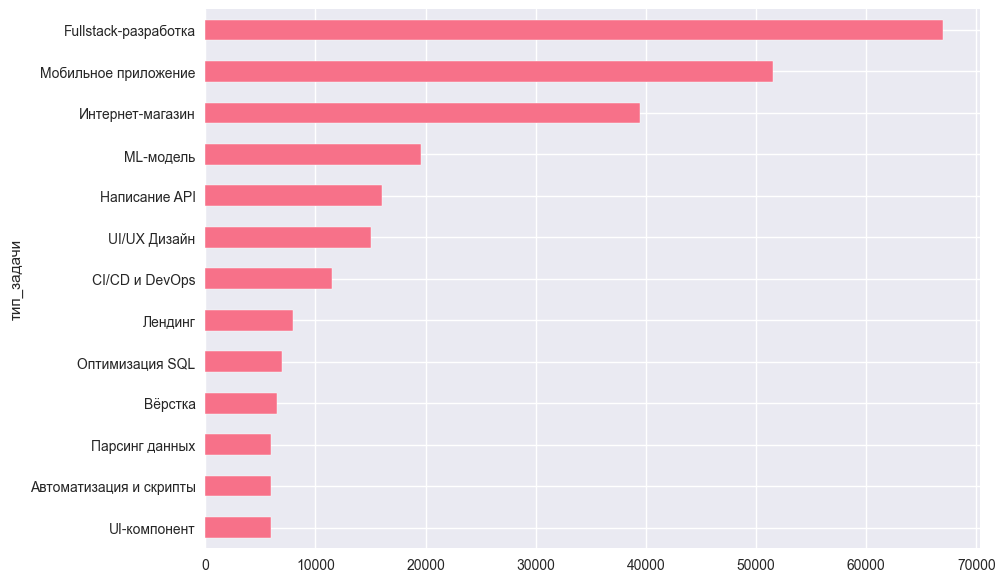

In [31]:
#медиана
med = df.groupby("тип_задачи")["цена_руб"].median()
med.sort_values().plot(kind="barh", figsize=(10, 7))


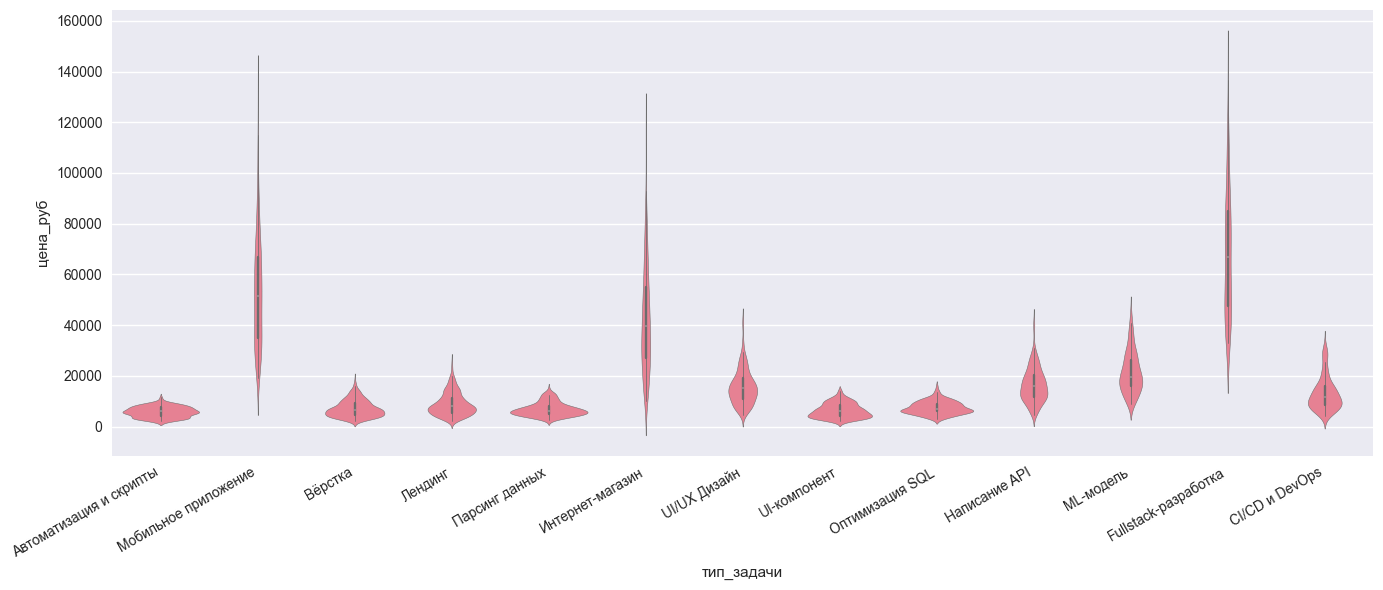

In [32]:
plt.figure(figsize=(14, 6))

sns.violinplot(
    data=df,
    x="тип_задачи",
    y="цена_руб"
)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Вывод

Тип задачи существенно влияет на стоимость проекта.

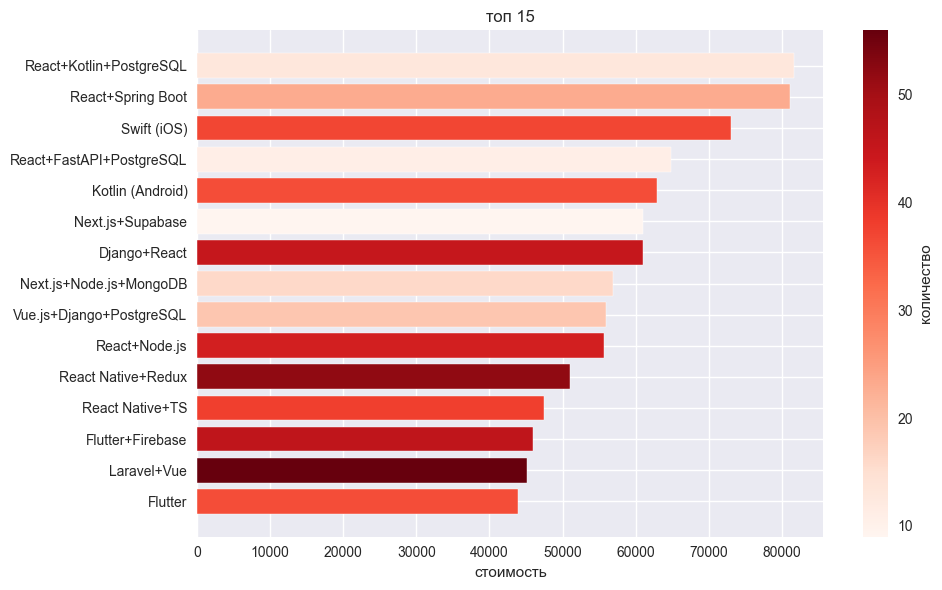

In [ ]:
group = df.groupby("технологический_стек")["цена_руб"].agg(["mean", "count"])
top15 = group.sort_values("mean", ascending=0).head(15)
top15 = top15.reset_index()

norm = matplotlib.colors.Normalize(vmin=top15["count"].min(), vmax=top15["count"].max())
palette = plt.colormaps["Reds"]
colors = palette(norm(top15["count"]))

fig, ax = plt.subplots(figsize = (10, 6))
ax.barh(y = range(len(top15)), width = top15["mean"], color = colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["технологический_стек"])
ax.invert_yaxis()

sm = plt.cm.ScalarMappable(norm=norm, cmap=palette)
fig.colorbar(sm, ax=ax, label="количество")

ax.set_xlabel("стоимость")
ax.set_title("топ 15")
plt.tight_layout()
plt.show()


### Вывод

Некоторые технологические стеки имеют значительно более высокую среднюю стоимость.

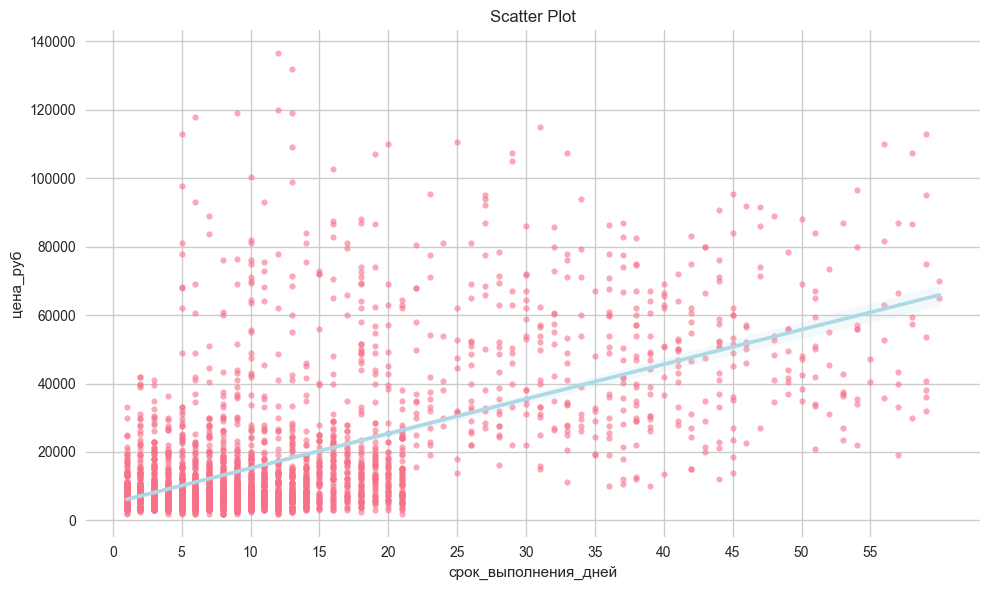

Correlation = 0.450
p-value = 2.3895e-149


In [34]:

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="срок_выполнения_дней",
    y="цена_руб",
    scatter_kws={"s": 20, "alpha": 0.6},
    line_kws={"color": "lightblue"}
)
plt.xticks(np.arange(0, 60, 5))
plt.title("Scatter Plot")
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr

corr, p = spearmanr(df["срок_выполнения_дней"], df["цена_руб"])

print(f"Correlation = {corr:.3f}")
print(f"p-value = {p:.5}")

### Вывод

Между сроком выполнения и стоимостью положительная зависимость.

# Подготовка данных

In [35]:
#3
df_model = df.drop(columns=["id", "ценовой_диапазон", "наименование_задачи"]).copy()

df_model["цена_руб"] = np.log(df_model["цена_руб"])

df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop("цена_руб", axis=1)
Y = df_model["цена_руб"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

### Удаление признака

Столюец "наименование_задачи" удален, так как содержит большое количество уникальных текстовых значений и не даёт существенного прироста качества модели.

### Кодирование категориальных признаков

Для категориальных признаков используется One-Hot Encoding

In [44]:
linear = LinearRegression()
linear.fit(X_train, Y_train)
# предсказание в рублях
Y_pred_lin_real = np.exp(linear.predict(X_test))

#тест в рублях
Y_test_real = np.exp(Y_test)

mae_lin = mean_absolute_error(Y_test_real, Y_pred_lin_real)
r2_lin = r2_score(Y_test_real, Y_pred_lin_real)


forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train, Y_train)
Y_pred_forest_real = np.exp(forest.predict(X_test))

mae_forest = mean_absolute_error(Y_test_real, Y_pred_forest_real)
r2_forest = r2_score(Y_test_real, Y_pred_forest_real)

results = pd.DataFrame({
    "Модель": ["Linear Regression", "Random Forest"],
    "MAE (руб.)": [mae_lin, mae_forest],
    "R^2": [r2_lin, r2_forest]
})

print(results)





              Модель    MAE (руб.)       R^2
0  Linear Regression  13279.177368 -0.131020
1      Random Forest  14824.700629 -0.216945


### Вывод

Random Forest показал более высокое качество по сравнению с базовой моделью

In [37]:
df_class = df.copy()

df_class["ценовой_диапазон"] = df_class["ценовой_диапазон"].replace({
    "свыше 120 000 ₽": "60 000+ ₽",
    "60 000–120 000 ₽": "60 000+ ₽",
})

print("Баланс классов после объединения:")
print(df_class["ценовой_диапазон"].value_counts())


Баланс классов после объединения:
ценовой_диапазон
5 000–15 000 ₽     1560
15 000–30 000 ₽     535
до 5 000 ₽          382
30 000–60 000 ₽     323
60 000+ ₽           200
Name: count, dtype: int64


### Подготовка классов

Редкие ценовые категории объединены для уменьшения дисбаланса

In [38]:
y_cls = df_class["ценовой_диапазон"]

X_cls = df_class.drop(columns=["id", "наименование_задачи", "цена_руб", "ценовой_диапазон"])
X_cls = pd.get_dummies(X_cls, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

classifier = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

15 000–30 000 ₽       0.43      0.57      0.49       107
30 000–60 000 ₽       0.47      0.48      0.47        65
 5 000–15 000 ₽       0.80      0.52      0.63       312
      60 000+ ₽       0.41      0.47      0.44        40
     до 5 000 ₽       0.39      0.72      0.51        76

       accuracy                           0.55       600
      macro avg       0.50      0.55      0.51       600
   weighted avg       0.62      0.55      0.56       600



### Вывод

Модель успешно определяет большинство ценовых диапазонов, сохраняя баланс между precision и recall.

# Анализ важности признаков

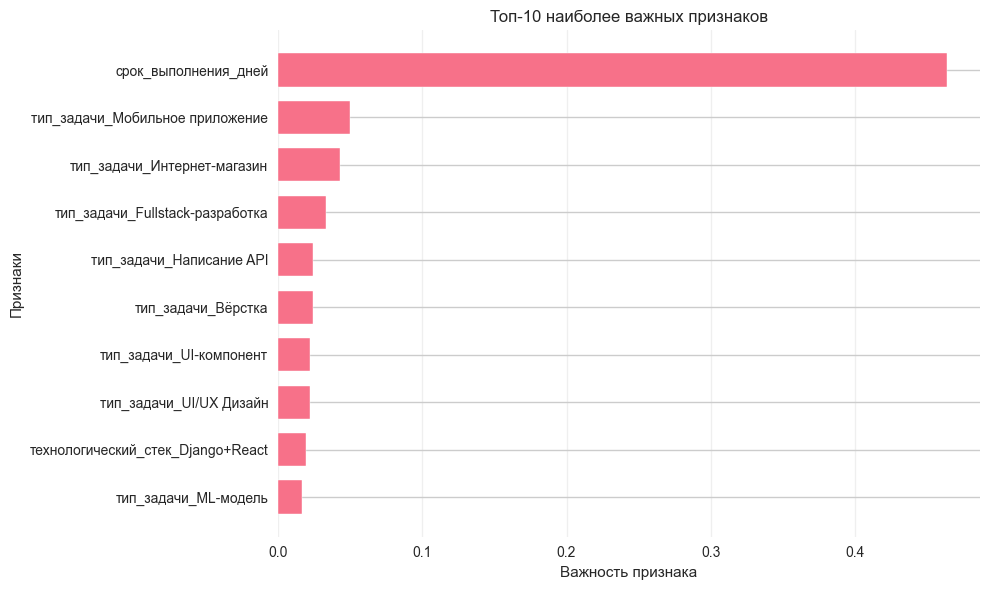

                                Признак  Важность
0                  срок_выполнения_дней  0.463448
9       тип_задачи_Мобильное приложение  0.049631
7           тип_задачи_Интернет-магазин  0.043210
1       тип_задачи_Fullstack-разработка  0.033268
10             тип_задачи_Написание API  0.024446
..                                  ...       ...
14         технологический_стек_Angular  0.000824
71      технологический_стек_SQL Server  0.000800
69  технологический_стек_React+Tailwind  0.000757
17        технологический_стек_BigQuery  0.000716
18      технологический_стек_ClickHouse  0.000685

[89 rows x 2 columns]


In [39]:
#6

importance = pd.DataFrame({
    "Признак": X_train.columns,
    "Важность": classifier.feature_importances_
})

importance = importance.sort_values(
    by="Важность",
    ascending=False
)

top10 = importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Признак"],
    top10["Важность"],
    height=0.7
)

plt.gca().invert_yaxis()

plt.title("Топ-10 наиболее важных признаков")
plt.xlabel("Важность признака")
plt.ylabel("Признаки")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
print(importance)

### Вывод

Наибольший вклад в прогноз вносят тип задачи, технологический стек и срок выполнения

# Улучшение модели

Для уменьшения числа разреженных признаков вместо One-Hot для технологического стека применяется Target Encoding. Это позволяет заменить большое количество бинарных признаков одним числовым признаком, содержащим информацию о средней стоимости проектов для каждого стека.

In [40]:
# Улучшение:
#уменьшить количество разреженных признаков и сделать признак более информативным.

df_te = df.drop(columns=["id", "наименование_задачи", "ценовой_диапазон"])
df_te["цена_руб"] = np.log(df_te["цена_руб"])

train_te, test_te = train_test_split(df_te, test_size=0.2, random_state=42)

stack_m = train_te.groupby("технологический_стек")["цена_руб"].mean()
global_m = train_te["цена_руб"].mean()

train_te["стек"] = train_te["технологический_стек"].map(stack_m).fillna(global_m)
test_te["стек"] = test_te["технологический_стек"].map(stack_m).fillna(global_m)

train_te = pd.get_dummies(
    train_te.drop(columns=["технологический_стек"]),
    columns=["тип_задачи"],
    drop_first=True
)

test_te = pd.get_dummies(
    test_te.drop(columns=["технологический_стек"]),
    columns=["тип_задачи"],
    drop_first=True
)

#+ отсутствующие категории в тест
test_te = test_te.reindex(columns=train_te.columns, fill_value=0)

X_train_te = train_te.drop(columns="цена_руб")
y_train_te = train_te["цена_руб"]

X_test_te = test_te.drop(columns="цена_руб")
y_test_te = test_te["цена_руб"]

print(f"Признаков было (One-Hot): {X_train.shape[1]}")
print(f"Признаков стало (Target Encoding): {X_train_te.shape[1]}")

Признаков было (One-Hot): 89
Признаков стало (Target Encoding): 14


In [41]:
forest_te = RandomForestRegressor(random_state=42)
forest_te.fit(X_train_te, y_train_te)

y_pred = np.exp(forest_te.predict(X_test_te))
y_real = np.exp(y_test_te)

mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)

print(f"MAE: {mae:.2f} руб.")
print(f"R^2: {r2:.3f}")

MAE: 6073.46 руб.
R^2: 0.750


In [ ]:
#кросс-валидация
cv_onehot = cross_val_score(
    RandomForestRegressor(random_state=42),
    X,
    Y,
    cv = 5,
    scoring="r2"
)

print(f"Onehot: r^2 = {cv_onehot.mean():.3f} +- {cv_onehot.std():.3f}")

X_te = pd.concat([X_train_te, X_test_te])
y_te = pd.concat([y_train_te, y_test_te])

cv_target = cross_val_score(
    RandomForestRegressor(random_state=42),
    X_te,
    y_te,
    cv= 5,
    scoring="r2"
)

print(f"Target Encoding: R^2 = {cv_target.mean():.3f} +- {cv_target.std():.3f}")

Onehot: r^2 = 0.779 +- 0.016
Target Encoding: R² = 0.782 +- 0.018


### Вывод

Target Encoding уменьшил размерность признаков и показал более высокое качество по сравнению с One-Hot